## Ejercicio 1

Implemente un algoritmo de optimización por enjambre de partículas y utilícelo para encontrar el mínimo global de las funciones del Ejercicio 1 de la Guía de trabajos prácticos 6.

Compare los resultados en relación a los obtenidos con algoritmos genéticos, en términos de las soluciones encontradas y la velocidad de convergencia.

### Idea del enjambre de partículas

Cada partícula es un punto ($x$ o $(x, y)$) que se mueve con una velocidad. Recuerda **su mejor posición** $y_k$ y todo el enjambre conoce **la mejor de todas** $\hat{y}$. En cada iteración la velocidad se corrige hacia esos dos lugares.

```mermaid
flowchart TD
    A["Posiciones al azar<br/>velocidades en 0"] --> B["Mejor global:<br/>el mejor de los<br/>mejores propios"]
    B --> C["Nueva velocidad<br/>de cada partícula"]
    C --> D["Mover: x ← x + v<br/>(sin salir de los límites)"]
    D --> E["Si f(x) mejoró,<br/>actualizar su mejor propio"]
    E --> F{"¿Llegué al máximo<br/>de iteraciones?"}
    F -- No --> B
    F -- Sí --> Z(["Fin: el mejor global"])
```

$$v \leftarrow \underbrace{w\, v}_{\text{lo que traía}} + \underbrace{c_1 r_1 (y_k - x)}_{\text{hacia su mejor}} + \underbrace{c_2 r_2 (\hat{y} - x)}_{\text{hacia el mejor del enjambre}}$$

- $r_1, r_2$: números al azar entre 0 y 1, nuevos en cada dimensión. Hacen que no todas vayan exactamente al mismo lugar (cumplen el papel de la mutación).
- $w = 0.73$ (inercia) y $c_1 = c_2 = 1.5$: los valores habituales del apunte.
- No hay codificación binaria: las partículas se mueven directamente en los números reales.

**Para comparar en igualdad de condiciones**, el algoritmo genético es el del TP6 y los dos usan 20 individuos/partículas y 100 iteraciones: cada iteración evalúa $f$ 20 veces en los dos métodos.

In [1]:
import math
import random
import pandas as pd
import matplotlib.pyplot as plt

#evaluo f en un punto guardado como lista: [x] o [x, y]
def f1(punto):
    x = punto[0]
    return -x * math.sin(math.sqrt(abs(x)))         #[-512, 512] minimo: -418.98

def f2(punto):
    x = punto[0]
    y = punto[1]
    return (x**2 + y**2)**0.25 * (math.sin(50 * (x**2 + y**2)**0.1)**2 + 1)     #[-100, 100] minimo: 0

#enjambre de particulas (mejor global)
#cada particula tiene: posicion x, velocidad v y la mejor posicion que encontro (mejor propio)
#el enjambre recuerda la mejor posicion de todas (mejor global)
def enjambre(funcion, limites, n_particulas=20, iteraciones=100, w=0.73, c1=1.5, c2=1.5):
    dimensiones = len(limites)

    #posiciones al azar dentro de los limites y velocidades en 0
    posiciones = []
    velocidades = []
    for k in range(n_particulas):
        x = []
        for i in range(dimensiones):
            a, b = limites[i]
            x.append(random.uniform(a, b))
        posiciones.append(x)
        velocidades.append([0] * dimensiones)

    #al principio el mejor propio de cada particula es donde esta
    mejores_propios = []
    f_propios = []
    for k in range(n_particulas):
        mejores_propios.append(posiciones[k][:])
        f_propios.append(funcion(posiciones[k]))

    historia = []       #mejor f del enjambre en cada iteracion, para graficar
    fotos = []          #posiciones de las particulas en cada iteracion, para graficar

    for it in range(iteraciones):

        #1. busco el mejor global entre los mejores propios
        g = f_propios.index(min(f_propios))
        mejor_global = mejores_propios[g][:]
        historia.append(f_propios[g])
        fotos.append([x[:] for x in posiciones])

        #2. muevo cada particula, dimension por dimension
        for k in range(n_particulas):
            for i in range(dimensiones):
                r1 = random.random()
                r2 = random.random()
                cognitivo = c1 * r1 * (mejores_propios[k][i] - posiciones[k][i])     #hacia su mejor
                social = c2 * r2 * (mejor_global[i] - posiciones[k][i])              #hacia el mejor del enjambre
                velocidades[k][i] = w * velocidades[k][i] + cognitivo + social
                posiciones[k][i] = posiciones[k][i] + velocidades[k][i]

                #si se sale de los limites la dejo en el borde
                a, b = limites[i]
                if posiciones[k][i] < a:
                    posiciones[k][i] = a
                if posiciones[k][i] > b:
                    posiciones[k][i] = b

            #3. si la nueva posicion es mejor que su mejor propio, lo actualizo
            f_nueva = funcion(posiciones[k])
            if f_nueva < f_propios[k]:
                f_propios[k] = f_nueva
                mejores_propios[k] = posiciones[k][:]

    g = f_propios.index(min(f_propios))
    return mejores_propios[g], f_propios[g], historia, fotos

In [2]:
#algoritmo genetico del TP6 (mismas ideas: torneo, 20 bits por variable, cruce en un punto,
#mutacion 1/n_bits y reemplazo elitista), adaptado para recibir la funcion y los limites
BITS = 20

def real_a_binario(punto, limites):
    maximo = 2 ** BITS - 1
    bits = ''
    for i in range(len(punto)):
        a, b = limites[i]
        entero = round((punto[i] - a) / (b - a) * maximo)
        bits = bits + format(entero, '0' + str(BITS) + 'b')
    return bits

def binario_a_real(bits, limites):
    maximo = 2 ** BITS - 1
    punto = []
    for i in range(len(limites)):
        a, b = limites[i]
        entero = int(bits[i * BITS:(i + 1) * BITS], 2)
        punto.append(a + entero * (b - a) / maximo)
    return punto

#torneo de 2: elijo 2 al azar y gana el de menor f
def seleccion(poblacion, valores):
    i = random.randrange(len(poblacion))
    j = random.randrange(len(poblacion))
    if valores[i] < valores[j]:
        return poblacion[i]
    return poblacion[j]

def cruce(padre, madre):
    corte = random.randint(1, len(padre) - 1)
    return padre[:corte] + madre[corte:]

def mutacion(bits, probabilidad):
    adn = list(bits)
    for i in range(len(adn)):
        if random.random() < probabilidad:
            if adn[i] == '1':
                adn[i] = '0'
            else:
                adn[i] = '1'
    return ''.join(adn)

def algoritmo_genetico(funcion, limites, tam_poblacion=20, generaciones=100, reemplazo=0.9):
    poblacion = []
    for k in range(tam_poblacion):
        punto = []
        for i in range(len(limites)):
            a, b = limites[i]
            punto.append(random.uniform(a, b))
        poblacion.append(punto)

    historia = []       #mejor f de cada generacion, para graficar

    for generacion in range(generaciones):
        valores = []
        for individuo in poblacion:
            valores.append(funcion(individuo))
        historia.append(min(valores))

        #creo los hijos
        hijos = []
        for k in range(round(tam_poblacion * reemplazo)):
            padre = real_a_binario(seleccion(poblacion, valores), limites)
            madre = real_a_binario(seleccion(poblacion, valores), limites)
            hijo = mutacion(cruce(padre, madre), 1 / len(padre))
            hijos.append(binario_a_real(hijo, limites))

        #elitismo: conservo los mejores para completar la poblacion
        indices = list(range(tam_poblacion))
        indices.sort(key=lambda k: valores[k])
        mejores = []
        for k in range(tam_poblacion - len(hijos)):
            mejores.append(poblacion[indices[k]])
        poblacion = mejores + hijos

    valores = []
    for individuo in poblacion:
        valores.append(funcion(individuo))
    mejor = valores.index(min(valores))
    return poblacion[mejor], valores[mejor], historia

In [3]:
AZUL = "#2a78d6"     #algoritmo genetico
VERDE = "#3a9e5c"    #enjambre de particulas
GRIS = "#8a8a8a"     #funcion

#primera iteracion en la que el mejor quedo a menos de "tolerancia" del optimo (None si nunca llego)
def iteracion_de_llegada(historia, f_optimo, tolerancia):
    for it in range(len(historia)):
        if historia[it] - f_optimo < tolerancia:
            return it
    return None

#corro los dos metodos varias veces y armo la tabla comparativa
def comparar(funcion, limites, f_optimo, corridas=10, tolerancia=0.1):
    historias = {"Algoritmo genético": [], "Enjambre de partículas": []}
    filas = []
    for metodo in historias:
        valores = []
        llegadas = []
        for corrida in range(corridas):
            random.seed(corrida)
            if metodo == "Algoritmo genético":
                punto, valor, historia = algoritmo_genetico(funcion, limites)
            else:
                punto, valor, historia, fotos = enjambre(funcion, limites)
            valores.append(valor)
            historias[metodo].append(historia)
            llegada = iteracion_de_llegada(historia, f_optimo, tolerancia)
            if llegada is not None:
                llegadas.append(llegada)

        if len(llegadas) > 0:
            promedio_llegada = sum(llegadas) / len(llegadas)
        else:
            promedio_llegada = None
        filas.append([min(valores), sum(valores) / corridas, str(len(llegadas)) + "/" + str(corridas),
                      promedio_llegada])

    tabla = pd.DataFrame(filas, index=list(historias),
                         columns=["mejor f", "f promedio", "llegó al mínimo global", "iteración de llegada (promedio)"])
    return tabla, historias

#curva de convergencia: distancia al optimo del mejor, una linea por corrida
#el eje y es logaritmico porque la distancia baja muchos ordenes de magnitud
def graficar_convergencia(historias, f_optimo, titulo):
    colores = {"Algoritmo genético": AZUL, "Enjambre de partículas": VERDE}
    for metodo in historias:
        for n in range(len(historias[metodo])):
            distancias = []
            for valor in historias[metodo][n]:
                distancias.append(valor - f_optimo)
            if n == 0:
                plt.plot(distancias, color=colores[metodo], alpha=0.6, label=metodo)
            else:
                plt.plot(distancias, color=colores[metodo], alpha=0.6)
    plt.yscale("log")
    plt.xlabel("Iteración / generación")
    plt.ylabel("mejor f − f óptimo")
    plt.title(titulo)
    plt.legend()
    plt.show()

#dibujo la funcion de fondo y encima las particulas en algunas iteraciones
def graficar_enjambre(funcion, limites, fotos, iteraciones):
    fig, ejes = plt.subplots(1, len(iteraciones), figsize=(4 * len(iteraciones), 3.5))
    for n in range(len(iteraciones)):
        ax = ejes[n]
        it = iteraciones[n]
        if len(limites) == 1:
            a, b = limites[0]
            xs = []
            ys = []
            for i in range(500):
                x = a + i * (b - a) / 499
                xs.append(x)
                ys.append(funcion([x]))
            ax.plot(xs, ys, color=GRIS)
            for x in fotos[it]:
                ax.plot(x[0], funcion(x), "o", color=VERDE, markersize=7)
            ax.set_xlabel("x")
        else:
            (x_min, x_max), (y_min, y_max) = limites
            matriz = []
            for i in range(150):
                y = y_min + i * (y_max - y_min) / 149
                fila = []
                for j in range(150):
                    x = x_min + j * (x_max - x_min) / 149
                    fila.append(funcion([x, y]))
                matriz.append(fila)
            ax.imshow(matriz, extent=[x_min, x_max, y_min, y_max], origin="lower", cmap="Greys")
            for x in fotos[it]:
                ax.plot(x[0], x[1], "o", color=VERDE, markersize=5)
            ax.set_xlabel("x")
            ax.set_ylabel("y")
        ax.set_title("iteración " + str(it))
    plt.tight_layout()
    plt.show()

**Inciso 1**: $f(x) = -x \sin\left(\sqrt{|x|}\right), \quad -512 \leq x \leq 512$

Mínimo global: $f(420.97) \approx -418.98$. Una corrida "llega" cuando su mejor $f$ queda a menos de 0.1 del mínimo.

In [4]:
limites1 = [(-512, 512)]
tabla1, historias1 = comparar(f1, limites1, f_optimo=-418.9829)
tabla1

,mejor f,f promedio,llegó al mínimo global,iteración de llegada (promedio)
Algoritmo genético,-418.982887,-418.982809,10/10,27.0
Enjambre de partículas,-418.982887,-396.032206,8/10,3.5


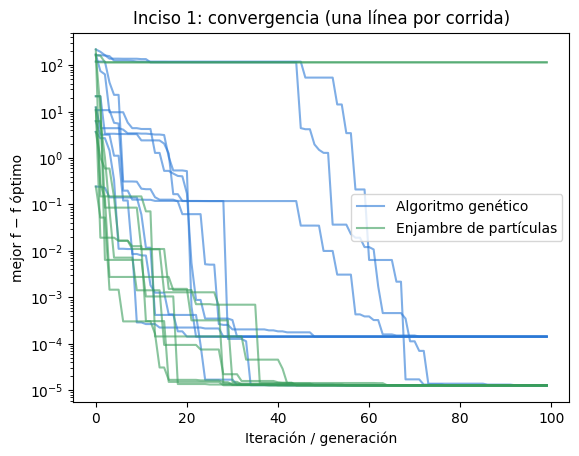

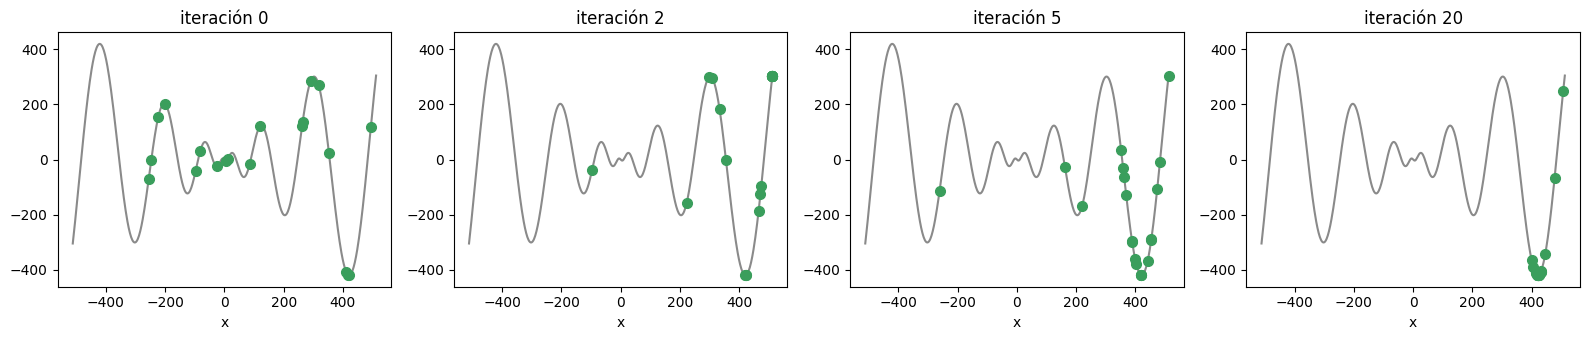

In [5]:
graficar_convergencia(historias1, -418.9829, "Inciso 1: convergencia (una línea por corrida)")

random.seed(0)
punto, valor, historia, fotos = enjambre(f1, limites1)
graficar_enjambre(f1, limites1, fotos, [0, 2, 5, 20])

**Inciso 2**: $f(x, y) = (x^2 + y^2)^{0.25} \left[\sin^2\left(50(x^2+y^2)^{0.1}\right) + 1\right], \quad -100 \leq x, y \leq 100$

Mínimo global: $f(0, 0) = 0$.

In [6]:
limites2 = [(-100, 100), (-100, 100)]
tabla2, historias2 = comparar(f2, limites2, f_optimo=0)
tabla2

,mejor f,f promedio,llegó al mínimo global,iteración de llegada (promedio)
Algoritmo genético,0.020752,0.111275,8/10,64.75
Enjambre de partículas,0.005703,0.016180,10/10,55.00


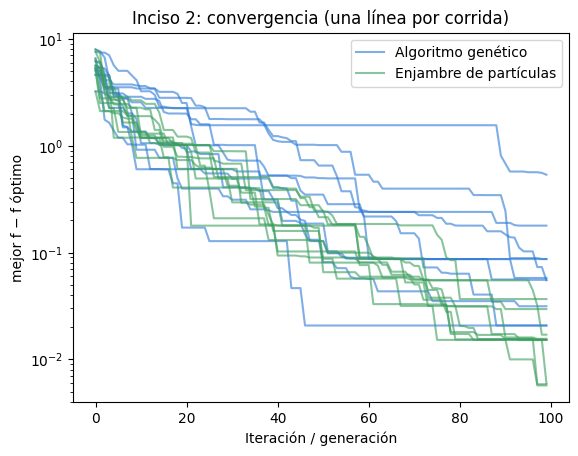

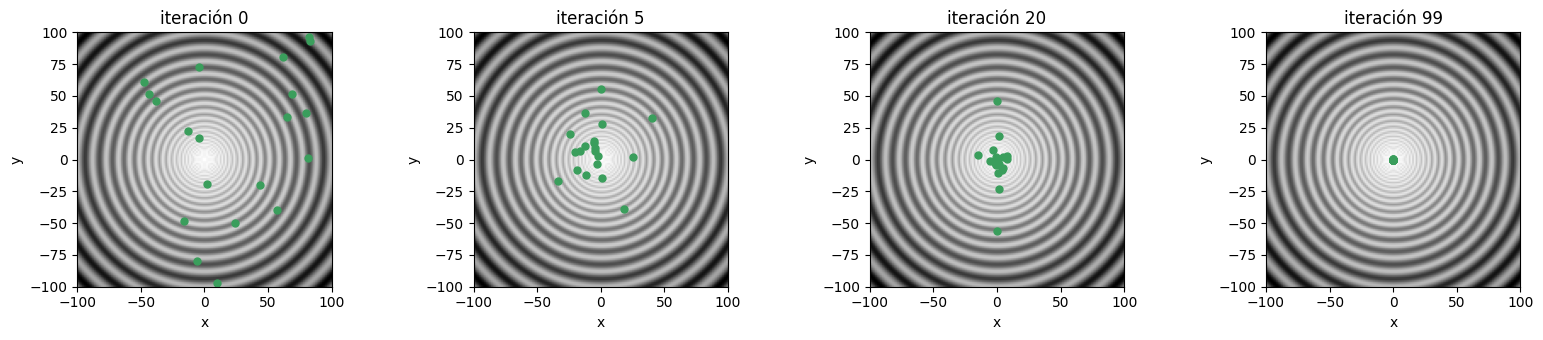

In [7]:
graficar_convergencia(historias2, 0, "Inciso 2: convergencia (una línea por corrida)")

random.seed(0)
punto, valor, historia, fotos = enjambre(f2, limites2)
graficar_enjambre(f2, limites2, fotos, [0, 5, 20, 99])

### Conclusiones

- **Velocidad de convergencia: el enjambre es más rápido.** Con la misma cantidad de evaluaciones de $f$ por iteración, en el inciso 1 llega al mínimo en la iteración 3.5 en promedio, contra 27 del algoritmo genético; en el inciso 2, 55 contra 65. Todas las partículas siguen al mejor del enjambre, así que apenas una encuentra el valle bueno las demás van hacia ahí.
- **Soluciones en el inciso 1: el genético es más confiable.** Llegó al mínimo global en 10 de 10 corridas y el enjambre en 8 de 10. En las 2 que fallaron, el enjambre se juntó en el borde $x = -512$ ($f = -304.2$), el segundo mejor valle: cuando todas las partículas están en el mismo lugar las atracciones valen 0, la velocidad se apaga y no sale más (convergencia prematura). El genético sigue explorando gracias a la mutación.
- **Soluciones en el inciso 2: gana el enjambre.** Llegó en 10 de 10 corridas, con $f$ promedio 0.016 contra 0.11 del genético (8 de 10). Las partículas se mueven en los números reales y se acercan al origen tanto como haga falta; el genético está limitado por la resolución de 20 bits y por los anillos de mínimos locales.
- **En resumen:** el enjambre es más simple (no hay codificación, cruce ni mutación) y converge más rápido, pero puede converger antes de tiempo a un mínimo local. El genético tarda más, pero explora más.

## Ejercicio 2

Suponga que un viajante tiene que visitar $n$ ciudades en el menor tiempo posible. Considere una matriz $D$ de tamaño $n \times n$ cuyos elementos $d_{pq}$ denotan la distancia entre cada par de ciudades $(p, q)$. Se define un *recorrido* como una trayectoria *cerrada* que visita cada ciudad una y sólo una vez (a excepción de la ciudad de partida, a la cual debe regresar). El problema consiste en hallar el recorrido de mínima longitud.

Implemente el algoritmo de sistema de hormigas y utilícelo para resolver el problema del agente viajero considerando los datos proporcionados en el archivo `gr17.csv`.

Analice el efecto de la *tasa de evaporación* ($\rho$) y de la *cantidad de feromona depositada* ($\tau$) sobre los resultados de la búsqueda. Para esto último compare el desempeño del algoritmo empleando los métodos *global*, *local* y *uniforme* para depósito de feromonas. Realice varias corridas con cada configuración experimental y considere el tiempo de búsqueda y la longitud de los caminos encontrados como medidas para comparar el desempeño. Construya una tabla comparativa con los resultados obtenidos.

### Idea del sistema de hormigas

Cada hormiga arma un recorrido completo eligiendo de a una ciudad. Al final de cada iteración las conexiones usadas reciben feromona, y en la iteración siguiente son más probables.

```mermaid
flowchart TD
    A["Feromonas iniciales<br/>chicas y al azar"] --> B["Cada hormiga arranca<br/>en una ciudad al azar"]
    B --> C["Elegir la próxima ciudad<br/>por ruleta (sólo entre<br/>las no visitadas)"]
    C --> D{"¿Visitó todas?"}
    D -- No --> C
    D -- Sí --> E["Volver a la primera<br/>y calcular el largo"]
    E --> F["Evaporar en todas<br/>las conexiones"]
    F --> G["Depositar en las<br/>conexiones usadas<br/>(global, uniforme o local)"]
    G --> H{"¿Todas hicieron<br/>el mismo camino o<br/>llegué al máximo<br/>de iteraciones?"}
    H -- No --> B
    H -- Sí --> Z(["Fin: el recorrido<br/>más corto encontrado"])
```

- **Probabilidad de ir de $i$ a $j$**: proporcional a $\sigma_{ij}^\alpha \, \eta_{ij}^\beta$, donde $\sigma_{ij}$ es la feromona de la conexión y $\eta_{ij} = 1/d_{ij}$ es el *deseo* (las ciudades cercanas atraen más). Las ciudades ya visitadas tienen probabilidad 0 (lista tabú).
- **Evaporación**: $\sigma_{ij} \leftarrow (1 - \rho)\, \sigma_{ij}$ en todas las conexiones.
- **Depósito**: cada hormiga $k$ suma $\Delta\sigma_{ij}^k$ en cada tramo $(i, j)$ de su recorrido:

| Método | $\Delta\sigma_{ij}^k$ | Qué premia |
|---|---|---|
| Global | $Q / L_k$ | que el recorrido completo sea corto |
| Uniforme | $Q$ | sólo que la hormiga pasó por ahí |
| Local | $Q / d_{ij}$ | que ese tramo sea corto |

El recorrido óptimo de `gr17` mide **2085** (es un problema de la biblioteca TSPLIB).

In [8]:
import csv
import random
import time
import pandas as pd
import matplotlib.pyplot as plt

#leo la matriz de distancias: la fila p, columna q es la distancia entre las ciudades p y q
distancias = []
with open("gr17.csv") as archivo:
    for fila in csv.reader(archivo):
        valores = []
        for v in fila:
            valores.append(float(v))
        distancias.append(valores)

n_ciudades = len(distancias)
print("ciudades:", n_ciudades)
print("distancias desde la ciudad 0:", distancias[0])

ciudades: 17
distancias desde la ciudad 0: [0.0, 633.0, 257.0, 91.0, 412.0, 150.0, 80.0, 134.0, 259.0, 505.0, 353.0, 324.0, 70.0, 211.0, 268.0, 246.0, 121.0]


In [9]:
#largo de un recorrido cerrado: sumo cada tramo y al final vuelvo a la ciudad de partida
def longitud(recorrido):
    total = 0
    for i in range(len(recorrido) - 1):
        total = total + distancias[recorrido[i]][recorrido[i + 1]]
    total = total + distancias[recorrido[-1]][recorrido[0]]
    return total

#feromonas iniciales: valores chicos al azar entre 0 y sigma0
def inicializar_feromonas(sigma0):
    feromonas = []
    for i in range(n_ciudades):
        fila = []
        for j in range(n_ciudades):
            fila.append(random.uniform(0, sigma0))
        feromonas.append(fila)
    return feromonas

#la hormiga esta en "actual" y elige la proxima ciudad entre las que todavia no visito (lista tabu)
#cada candidata tiene un peso feromona^alfa * (1/distancia)^beta, y se elige por ruleta
def elegir_siguiente(actual, visitadas, feromonas, alfa, beta):
    candidatas = []
    pesos = []
    for j in range(n_ciudades):
        if j not in visitadas:
            deseo = 1 / distancias[actual][j]
            candidatas.append(j)
            pesos.append(feromonas[actual][j] ** alfa * deseo ** beta)

    #ruleta: tiro un numero entre 0 y la suma de los pesos y veo en que porcion cae
    tiro = random.uniform(0, sum(pesos))
    acumulado = 0
    for i in range(len(candidatas)):
        acumulado = acumulado + pesos[i]
        if tiro <= acumulado:
            return candidatas[i]
    return candidatas[-1]

#una hormiga arranca en una ciudad al azar y va eligiendo hasta visitarlas todas
def construir_recorrido(feromonas, alfa, beta):
    actual = random.randrange(n_ciudades)
    recorrido = [actual]
    while len(recorrido) < n_ciudades:
        actual = elegir_siguiente(actual, recorrido, feromonas, alfa, beta)
        recorrido.append(actual)
    return recorrido

#evaporacion: en TODAS las conexiones queda (1 - rho) de lo que habia
def evaporar(feromonas, rho):
    for i in range(n_ciudades):
        for j in range(n_ciudades):
            feromonas[i][j] = (1 - rho) * feromonas[i][j]

#deposito: cada hormiga deja feromona en los tramos que uso
#  global:   Q / largo del recorrido completo
#  uniforme: Q
#  local:    Q / distancia del tramo
def depositar(feromonas, recorridos, metodo, Q):
    for recorrido in recorridos:
        largo = longitud(recorrido)
        for i in range(n_ciudades):
            p = recorrido[i]
            q = recorrido[(i + 1) % n_ciudades]     #el ultimo tramo vuelve a la ciudad de partida

            if metodo == "global":
                cantidad = Q / largo
            if metodo == "uniforme":
                cantidad = Q
            if metodo == "local":
                cantidad = Q / distancias[p][q]

            #la matriz es simetrica: ir de p a q es lo mismo que ir de q a p
            feromonas[p][q] = feromonas[p][q] + cantidad
            feromonas[q][p] = feromonas[q][p] + cantidad

#conjunto de tramos de un recorrido, sin importar el sentido ni la ciudad de partida
#sirve para saber si dos hormigas hicieron el mismo camino
def tramos(recorrido):
    conjunto = set()
    for i in range(n_ciudades):
        p = recorrido[i]
        q = recorrido[(i + 1) % n_ciudades]
        conjunto.add((min(p, q), max(p, q)))
    return conjunto

In [10]:
def sistema_de_hormigas(metodo, rho, Q=1, n_hormigas=10, alfa=1, beta=1, sigma0=0.1, max_iteraciones=200):
    inicio = time.time()
    feromonas = inicializar_feromonas(sigma0)
    mejor = None
    mejor_largo = float("inf")
    historia = []       #mejor largo encontrado hasta cada iteracion, para graficar

    for iteracion in range(1, max_iteraciones + 1):

        #1. cada hormiga construye su recorrido
        recorridos = []
        for k in range(n_hormigas):
            recorridos.append(construir_recorrido(feromonas, alfa, beta))

        #2. guardo el mejor recorrido visto hasta ahora
        for recorrido in recorridos:
            if longitud(recorrido) < mejor_largo:
                mejor_largo = longitud(recorrido)
                mejor = recorrido
                iteracion_mejor = iteracion                 #en que iteracion lo encontre
                tiempo_mejor = time.time() - inicio         #y cuanto tarde en encontrarlo
        historia.append(mejor_largo)

        #3. actualizo feromonas: primero evaporo en todas, despues deposito en las usadas
        evaporar(feromonas, rho)
        depositar(feromonas, recorridos, metodo, Q)

        #4. termino si todas las hormigas hicieron el mismo camino
        todas_iguales = True
        for recorrido in recorridos:
            if tramos(recorrido) != tramos(recorridos[0]):
                todas_iguales = False
        if todas_iguales:
            break

    return mejor, mejor_largo, historia, iteracion_mejor, tiempo_mejor

### Experimentos

Pruebo los 3 métodos de depósito con 4 tasas de evaporación, 10 corridas por configuración. Los demás parámetros quedan fijos: 10 hormigas, $\alpha = 1$, $\beta = 1$, $Q = 1$ y como máximo 200 iteraciones.

- **Largo**: el mejor recorrido de cada corrida (óptimo = 2085).
- **Tiempo de búsqueda**: segundos e iteraciones hasta encontrar ese mejor recorrido.

Uso $\beta = 1$ porque con $\beta = 2$ el deseo $1/d$ pesa tanto que todas las configuraciones llegan al óptimo y no se ve el efecto de $\rho$ ni del depósito.

In [11]:
metodos = ["global", "uniforme", "local"]
tasas = [0.01, 0.1, 0.5, 0.9]
corridas = 10
OPTIMO = 2085

filas = []
historias = {}      #historias[(metodo, rho)] = lista con la historia de cada corrida

for metodo in metodos:
    for rho in tasas:
        largos = []
        iteraciones = []
        tiempos = []
        historias[(metodo, rho)] = []

        for corrida in range(corridas):
            random.seed(corrida)
            mejor, mejor_largo, historia, iteracion_mejor, tiempo_mejor = sistema_de_hormigas(metodo, rho)
            largos.append(mejor_largo)
            iteraciones.append(iteracion_mejor)
            tiempos.append(tiempo_mejor)
            historias[(metodo, rho)].append(historia)

        filas.append([metodo, rho, min(largos), sum(largos) / corridas, max(largos),
                      str(largos.count(OPTIMO)) + "/" + str(corridas),
                      sum(iteraciones) / corridas, sum(tiempos) / corridas])

tabla = pd.DataFrame(filas, columns=["depósito", "ρ", "mejor largo", "largo promedio", "peor largo",
                                     "llegó al óptimo", "iteraciones promedio", "tiempo promedio (s)"])
tabla.round(2)

,depósito,ρ,mejor largo,largo promedio,peor largo,llegó al óptimo,iteraciones promedio,tiempo promedio (s)
0,global,0.01,2160.0,2242.3,2287.0,0/10,157.6,0.35
1,global,0.10,2085.0,2102.3,2132.0,2/10,165.8,0.36
2,global,0.50,2085.0,2107.8,2149.0,1/10,120.6,0.26
3,global,0.90,2085.0,2121.6,2160.0,1/10,82.3,0.18
4,uniforme,0.01,2085.0,2124.8,2173.0,1/10,128.9,0.27
5,uniforme,0.10,2085.0,2104.4,2152.0,4/10,145.1,0.28
6,uniforme,0.50,2085.0,2116.6,2158.0,1/10,103.0,0.21
7,uniforme,0.90,2085.0,2124.3,2167.0,1/10,125.1,0.27
8,local,0.01,2085.0,2093.4,2115.0,4/10,129.7,0.31
9,local,0.10,2085.0,2091.3,2105.0,5/10,81.9,0.19


### Efecto de la tasa de evaporación

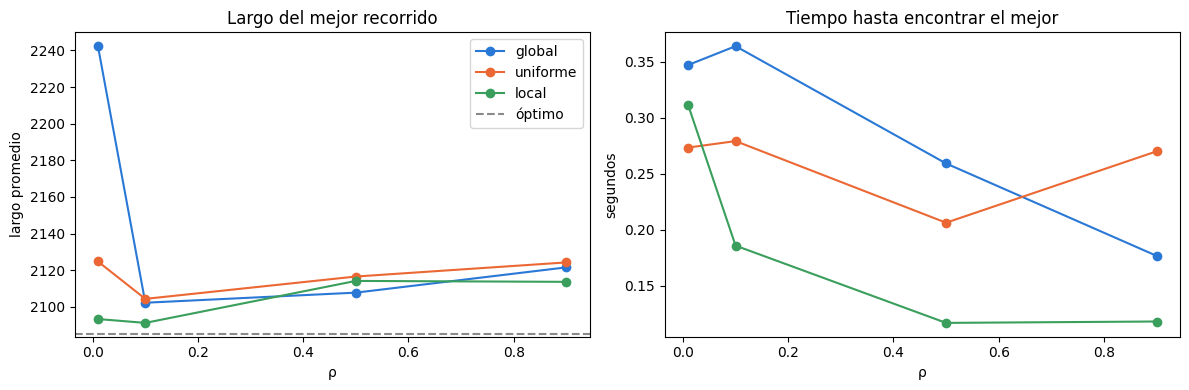

In [12]:
COLORES = {"global": "#2a78d6", "uniforme": "#eb6834", "local": "#3a9e5c"}

#largo promedio segun rho, una linea por metodo
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
for metodo in metodos:
    largos_promedio = []
    tiempos_promedio = []
    for fila in filas:
        if fila[0] == metodo:
            largos_promedio.append(fila[3])
            tiempos_promedio.append(fila[7])
    ejes[0].plot(tasas, largos_promedio, "o-", color=COLORES[metodo], label=metodo)
    ejes[1].plot(tasas, tiempos_promedio, "o-", color=COLORES[metodo], label=metodo)

ejes[0].axhline(OPTIMO, color="#8a8a8a", linestyle="--", label="óptimo")
ejes[0].set_xlabel("ρ")
ejes[0].set_ylabel("largo promedio")
ejes[0].set_title("Largo del mejor recorrido")
ejes[1].set_xlabel("ρ")
ejes[1].set_ylabel("segundos")
ejes[1].set_title("Tiempo hasta encontrar el mejor")
ejes[0].legend()
plt.tight_layout()
plt.show()

### Comparación de los métodos de depósito

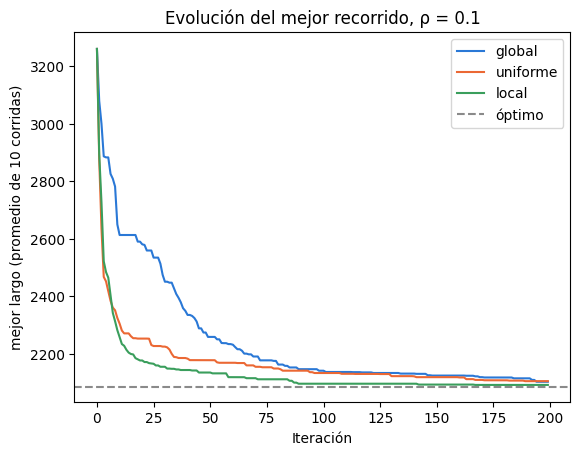

In [13]:
#evolucion del mejor largo con rho = 0.1: promedio de las 10 corridas para cada metodo
rho = 0.1
for metodo in metodos:
    promedio = []
    for it in range(len(historias[(metodo, rho)][0])):
        suma = 0
        for historia in historias[(metodo, rho)]:
            suma = suma + historia[it]
        promedio.append(suma / corridas)
    plt.plot(promedio, color=COLORES[metodo], label=metodo)

plt.axhline(OPTIMO, color="#8a8a8a", linestyle="--", label="óptimo")
plt.xlabel("Iteración")
plt.ylabel("mejor largo (promedio de 10 corridas)")
plt.title("Evolución del mejor recorrido, ρ = " + str(rho))
plt.legend()
plt.show()

In [14]:
#una corrida de ejemplo: el recorrido que encontró (vuelve a la ciudad de partida)
random.seed(0)
mejor, mejor_largo, historia, iteracion_mejor, tiempo_mejor = sistema_de_hormigas("local", 0.1)
print("recorrido:", mejor + [mejor[0]])
print("largo:", mejor_largo)

recorrido: [8, 11, 15, 0, 3, 12, 6, 16, 7, 5, 13, 14, 2, 10, 9, 1, 4, 8]
largo: 2095.0


### Conclusiones

- **Tasa de evaporación.** El mejor valor fue $\rho = 0.1$ en los tres métodos. Con $\rho = 0.01$ lo que se depositó al principio (y las feromonas iniciales al azar) casi no se borra, y la colonia sigue reforzando caminos malos: es el peor caso, sobre todo con depósito global. Con $\rho$ grande (0.5 y 0.9) la colonia encuentra su mejor recorrido en menos iteraciones, pero ese recorrido es más largo: se olvida todo enseguida y no aprovecha lo aprendido (convergencia prematura).
- **Método de depósito.** El **local** fue el mejor: menor largo promedio (2091 con $\rho = 0.1$), llegó al óptimo en 5 de 10 corridas y fue el más rápido (82 iteraciones en promedio). Premia los tramos cortos, que es justamente lo que forma un buen recorrido. **Global** y **uniforme** terminan parecido, pero el global arranca más lento: con $Q = 1$ deposita $1/L \approx 0.0005$ por tramo, mucho menos que las feromonas iniciales (hasta 0.1), y tarda en imponerse. El uniforme deposita lo mismo para un recorrido bueno que para uno malo.
- **Tiempo.** Todas las corridas tardan menos de medio segundo. En ninguna todas las hormigas terminaron haciendo el mismo camino, así que siempre cortó por el máximo de iteraciones; por eso el tiempo de búsqueda se midió hasta encontrar el mejor recorrido.